In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# To display all columns clearly
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
df = pd.read_excel(r"C:\Users\user\Downloads\Dataset for Data Analytics (3).xlsx")
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [10]:
df.shape

(1200, 14)

In [12]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [15]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [16]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [17]:
df["CouponCode"] = df["CouponCode"].fillna("No Coupon")

# Confirm missing values again
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df["OrderID"].duplicated().sum()

np.int64(0)

In [21]:
df = df.drop_duplicates()

df.shape

(1200, 14)

In [22]:
# Select text/object columns
text_columns = df.select_dtypes(include="object").columns

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [23]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Check date range
df["Date"].min(), df["Date"].max()

(Timestamp('2023-01-01 00:00:00'), Timestamp('2025-06-30 00:00:00'))

In [24]:
# Create expected total price
df["ExpectedTotalPrice"] = (df["Quantity"] * df["UnitPrice"]).round(2)

# Check if TotalPrice matches ExpectedTotalPrice
df["PriceCheck"] = np.isclose(df["TotalPrice"], df["ExpectedTotalPrice"])

# Count incorrect price records
df["PriceCheck"].value_counts()

PriceCheck
True    1200
Name: count, dtype: int64

In [25]:
df[df["PriceCheck"] == False]

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,ExpectedTotalPrice,PriceCheck


In [26]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["MonthName"] = df["Date"].dt.month_name()
df["Quarter"] = df["Date"].dt.quarter
df["YearMonth"] = df["Date"].dt.to_period("M").astype(str)

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,ExpectedTotalPrice,PriceCheck,Year,Month,MonthName,Quarter,YearMonth
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2853.10,True,2023,1,January,1,2023-01
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,302.70,True,2024,8,August,3,2024-08
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2753.40,True,2024,2,February,1,2024-02
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,273.19,True,2023,10,October,4,2023-10
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2504.04,True,2025,5,May,2,2025-05


In [27]:
# Define successful order statuses
successful_statuses = ["Delivered", "Shipped"]

# Gross revenue includes all orders
df["GrossRevenue"] = df["TotalPrice"]

# Net revenue includes only delivered and shipped orders
df["NetRevenue"] = np.where(
    df["OrderStatus"].isin(successful_statuses),
    df["TotalPrice"],
    0
)

# Create success flag
df["SuccessfulOrder"] = np.where(
    df["OrderStatus"].isin(successful_statuses),
    "Yes",
    "No"
)

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,ExpectedTotalPrice,PriceCheck,Year,Month,MonthName,Quarter,YearMonth,GrossRevenue,NetRevenue,SuccessfulOrder
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2853.10,True,2023,1,January,1,2023-01,2853.10,2853.10,Yes
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,302.70,True,2024,8,August,3,2024-08,302.70,302.70,Yes
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2753.40,True,2024,2,February,1,2024-02,2753.40,0.00,No
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,273.19,True,2023,10,October,4,2023-10,273.19,0.00,No
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2504.04,True,2025,5,May,2,2025-05,2504.04,2504.04,Yes


In [30]:
total_orders = df["OrderID"].nunique()
total_customers = df["CustomerID"].nunique()
total_quantity_sold = df["Quantity"].sum()
gross_revenue = df["GrossRevenue"].sum()
net_revenue = df["NetRevenue"].sum()

successful_orders = df[df["SuccessfulOrder"] == "Yes"]["OrderID"].nunique()
cancelled_orders = df[df["OrderStatus"] == "Cancelled"]["OrderID"].nunique()
returned_orders = df[df["OrderStatus"] == "Returned"]["OrderID"].nunique()

average_order_value = gross_revenue / total_orders
net_average_order_value = net_revenue / successful_orders

cancellation_rate = cancelled_orders / total_orders * 100
return_rate = returned_orders / total_orders * 100
success_rate = successful_orders / total_orders * 100

kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Orders",
        "Total Customers",
        "Total Quantity Sold",
        "Gross Revenue",
        "Net Revenue",
        "Successful Orders",
        "Average Order Value",
        "Net Average Order Value",
        "Cancellation Rate (%)",
        "Return Rate (%)",
        "Success Rate (%)"
    ],
    "Value": [
        total_orders,
        total_customers,
        total_quantity_sold,
        gross_revenue,
        net_revenue,
        successful_orders,
        average_order_value,
        net_average_order_value,
        cancellation_rate,
        return_rate,
        success_rate
    ]
})

kpi_summary

,Metric,Value
0,Total Orders,1.200000e+03
1,Total Customers,1.189000e+03
2,Total Quantity Sold,3.535000e+03
3,Gross Revenue,1.264762e+06
4,Net Revenue,4.887599e+05
5,Successful Orders,4.660000e+02
6,Average Order Value,1.053968e+03
7,Net Average Order Value,1.048841e+03
8,Cancellation Rate (%),2.083333e+01
9,Return Rate (%),2.058333e+01


In [29]:
product_summary = df.groupby("Product").agg(
    Orders=("OrderID", "nunique"),
    QuantitySold=("Quantity", "sum"),
    GrossRevenue=("GrossRevenue", "sum"),
    NetRevenue=("NetRevenue", "sum"),
    AverageUnitPrice=("UnitPrice", "mean"),
    AverageOrderValue=("TotalPrice", "mean")
).reset_index()

product_summary = product_summary.sort_values(by="NetRevenue", ascending=False)

product_summary

,Product,Orders,QuantitySold,GrossRevenue,NetRevenue,AverageUnitPrice,AverageOrderValue
5,Printer,181,542,195612.61,82452.14,351.714917,1080.732652
2,Laptop,173,535,192126.56,80951.66,357.707052,1110.558150
0,Chair,178,562,195620.11,71816.27,355.660281,1098.989382
3,Monitor,163,480,175651.41,66924.44,358.663620,1077.616012
6,Tablet,179,497,186568.95,66622.67,367.679106,1042.284637
4,Phone,156,411,151722.39,62342.05,375.217564,972.579423
1,Desk,170,508,167459.93,57650.67,329.608118,985.058412


In [31]:
monthly_sales = df.groupby("YearMonth").agg(
    Orders=("OrderID", "nunique"),
    GrossRevenue=("GrossRevenue", "sum"),
    NetRevenue=("NetRevenue", "sum"),
    QuantitySold=("Quantity", "sum")
).reset_index()

monthly_sales = monthly_sales.sort_values("YearMonth")

monthly_sales.head()

,YearMonth,Orders,GrossRevenue,NetRevenue,QuantitySold
0,2023-01,47,56685.75,13339.68,146
1,2023-02,37,40117.66,8396.83,102
2,2023-03,43,48609.37,16099.56,126
3,2023-04,31,27751.71,13776.88,84
4,2023-05,49,63836.84,28673.90,148


In [40]:
order_status_summary = df.groupby("OrderStatus").agg(
    Orders=("OrderID", "nunique"),
    GrossRevenue=("GrossRevenue", "sum"),
    NetRevenue=("NetRevenue", "sum")
).reset_index()

order_status_summary = order_status_summary.sort_values(by="Orders", ascending=False)

order_status_summary

,OrderStatus,Orders,GrossRevenue,NetRevenue
0,Cancelled,250,276396.21,0.00
3,Returned,247,243277.70,0.00
2,Pending,237,256328.15,0.00
4,Shipped,235,246159.58,246159.58
1,Delivered,231,242600.32,242600.32


In [32]:
payment_summary = df.groupby("PaymentMethod").agg(
    Orders=("OrderID", "nunique"),
    GrossRevenue=("GrossRevenue", "sum"),
    NetRevenue=("NetRevenue", "sum"),
    AverageOrderValue=("TotalPrice", "mean")
).reset_index()

payment_summary = payment_summary.sort_values(by="Orders", ascending=False)

payment_summary

,PaymentMethod,Orders,GrossRevenue,NetRevenue,AverageOrderValue
4,Online,258,262442.94,123570.92,1017.220698
0,Cash,246,259786.29,90475.33,1056.041829
1,Credit Card,234,263847.63,87571.26,1127.553974
2,Debit Card,232,232361.18,91101.08,1001.556810
3,Gift Card,230,246323.92,96041.31,1070.973565


In [33]:
referral_summary = df.groupby("ReferralSource").agg(
    Orders=("OrderID", "nunique"),
    GrossRevenue=("GrossRevenue", "sum"),
    NetRevenue=("NetRevenue", "sum"),
    QuantitySold=("Quantity", "sum")
).reset_index()

referral_summary = referral_summary.sort_values(by="NetRevenue", ascending=False)

referral_summary

,ReferralSource,Orders,GrossRevenue,NetRevenue,QuantitySold
3,Instagram,259,275285.45,108246.78,770
0,Email,250,261808.55,100147.67,746
2,Google,241,250441.48,95567.23,714
1,Facebook,228,250410.90,93189.60,674
4,Referral,222,226815.58,91608.62,631


In [34]:
coupon_summary = df.groupby("CouponCode").agg(
    Orders=("OrderID", "nunique"),
    GrossRevenue=("GrossRevenue", "sum"),
    NetRevenue=("NetRevenue", "sum"),
    AverageOrderValue=("TotalPrice", "mean")
).reset_index()

coupon_summary = coupon_summary.sort_values(by="NetRevenue", ascending=False)

coupon_summary

,CouponCode,Orders,GrossRevenue,NetRevenue,AverageOrderValue
2,SAVE10,286,304840.02,131786.31,1065.874196
0,FREESHIP,313,335036.99,127122.99,1070.405719
1,No Coupon,309,322401.41,118847.93,1043.370259
3,WINTER15,292,302483.54,111002.67,1035.902534


In [35]:
customer_summary = df.groupby("CustomerID").agg(
    Orders=("OrderID", "nunique"),
    TotalQuantity=("Quantity", "sum"),
    GrossRevenue=("GrossRevenue", "sum"),
    NetRevenue=("NetRevenue", "sum"),
    FirstOrderDate=("Date", "min"),
    LastOrderDate=("Date", "max")
).reset_index()

customer_summary = customer_summary.sort_values(by="NetRevenue", ascending=False)

customer_summary.head(10)

,CustomerID,Orders,TotalQuantity,GrossRevenue,NetRevenue,FirstOrderDate,LastOrderDate
648,C57276,1,5,3456.40,3456.40,2023-08-17,2023-08-17
781,C67260,1,5,3390.80,3390.80,2023-05-02,2023-05-02
97,C16775,1,5,3353.75,3353.75,2023-03-27,2023-03-27
520,C47778,1,5,3334.00,3334.00,2023-10-30,2023-10-30
211,C25276,1,5,3313.90,3313.90,2023-05-26,2023-05-26
599,C53464,1,5,3299.25,3299.25,2024-06-29,2024-06-29
1028,C88029,1,5,3277.75,3277.75,2025-06-14,2025-06-14
1050,C89979,1,5,3170.00,3170.00,2024-06-20,2024-06-20
409,C39074,1,5,3032.60,3032.60,2023-10-25,2023-10-25
14,C11415,1,5,2876.20,2876.20,2024-03-15,2024-03-15


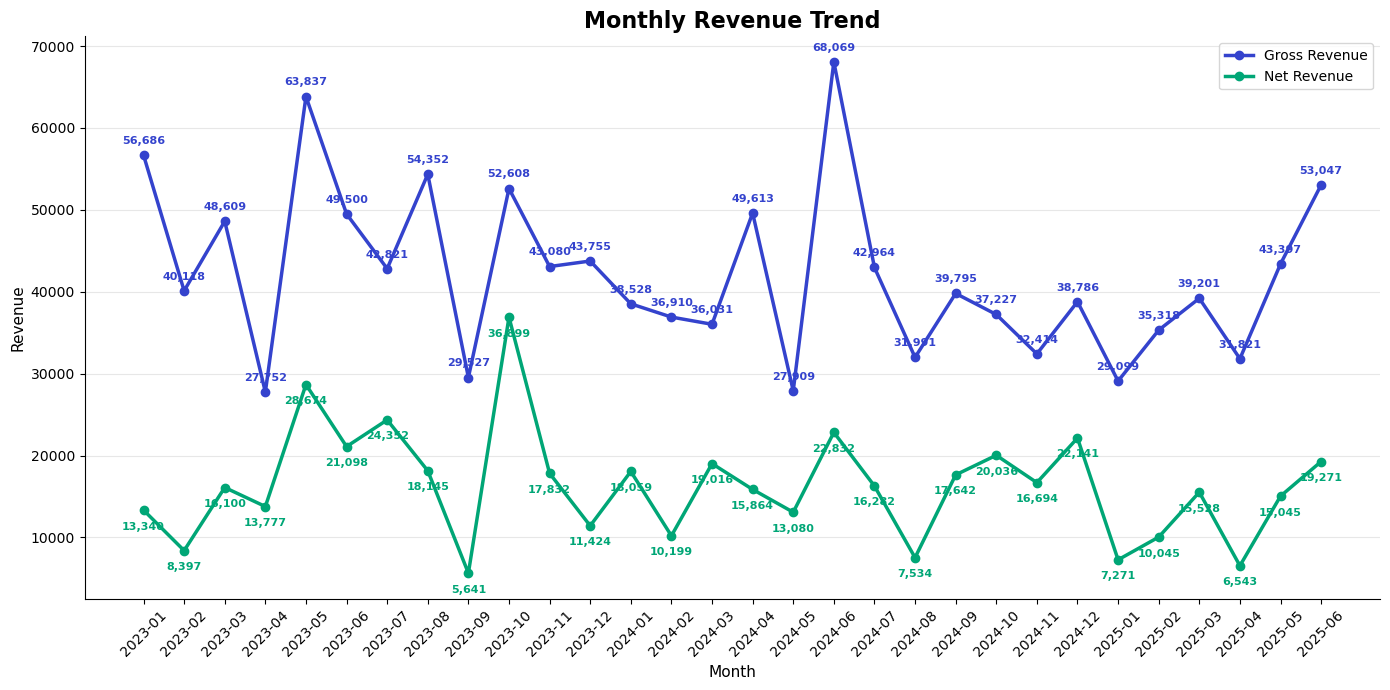

In [54]:
plt.figure(figsize=(14, 7))

plt.plot(
    monthly_sales["YearMonth"], 
    monthly_sales["GrossRevenue"], 
    marker="o", 
    linewidth=2.5,
    color="#3443CD",
    label="Gross Revenue"
)

plt.plot(
    monthly_sales["YearMonth"], 
    monthly_sales["NetRevenue"], 
    marker="o", 
    linewidth=2.5,
    color="#00A676",
    label="Net Revenue"
)

# Add formatted values with spacing
for i in range(len(monthly_sales)):
    month = monthly_sales["YearMonth"].iloc[i]
    gross = monthly_sales["GrossRevenue"].iloc[i]
    net = monthly_sales["NetRevenue"].iloc[i]
    
    plt.annotate(
        f"{gross:,.0f}",
        xy=(month, gross),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        fontweight="bold",
        color="#3443CD"
    )
    
    plt.annotate(
        f"{net:,.0f}",
        xy=(month, net),
        xytext=(0, -14),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        fontweight="bold",
        color="#00A676"
    )

plt.title("Monthly Revenue Trend", fontsize=16, fontweight="bold")
plt.xlabel("Month", fontsize=11)
plt.ylabel("Revenue", fontsize=11)

plt.xticks(rotation=45)
plt.legend()
plt.grid(axis="y", alpha=0.3)

# Remove top and right border
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

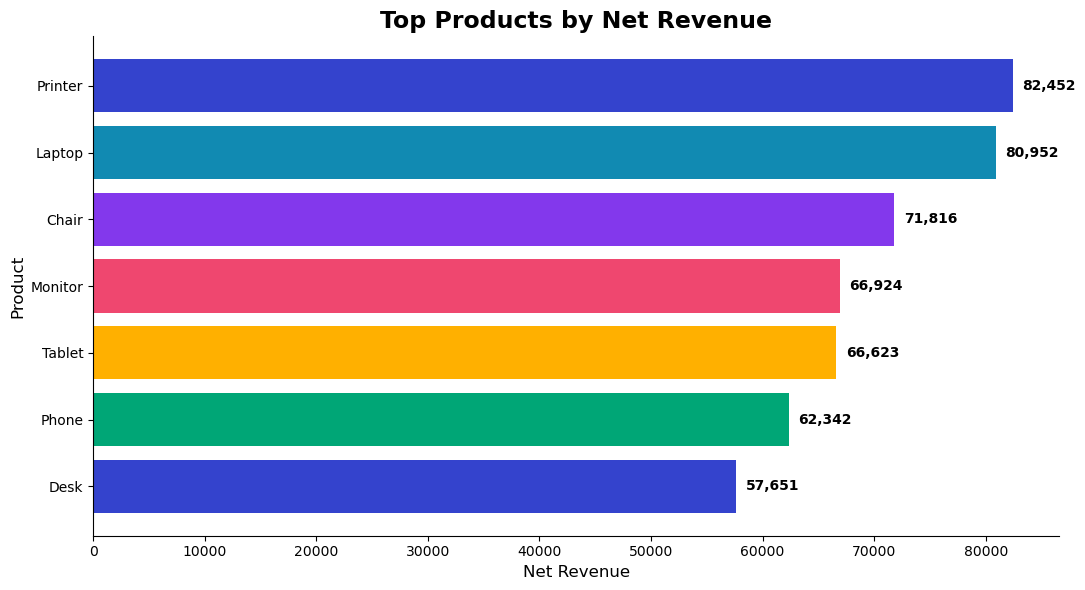

In [53]:
plt.figure(figsize=(11, 6))

product_sorted = product_summary.sort_values(by="NetRevenue", ascending=True)

colors = ["#3443CD", "#00A676", "#FFB000", "#EF476F", "#8338EC", "#118AB2"]

bars = plt.barh(
    product_sorted["Product"],
    product_sorted["NetRevenue"],
    color=colors[:len(product_sorted)]
)

plt.title("Top Products by Net Revenue", fontsize=17, fontweight="bold")
plt.xlabel("Net Revenue", fontsize=12)
plt.ylabel("Product", fontsize=12)

# Remove unnecessary chart borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + (product_sorted["NetRevenue"].max() * 0.01),
        bar.get_y() + bar.get_height() / 2,
        f"{width:,.0f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

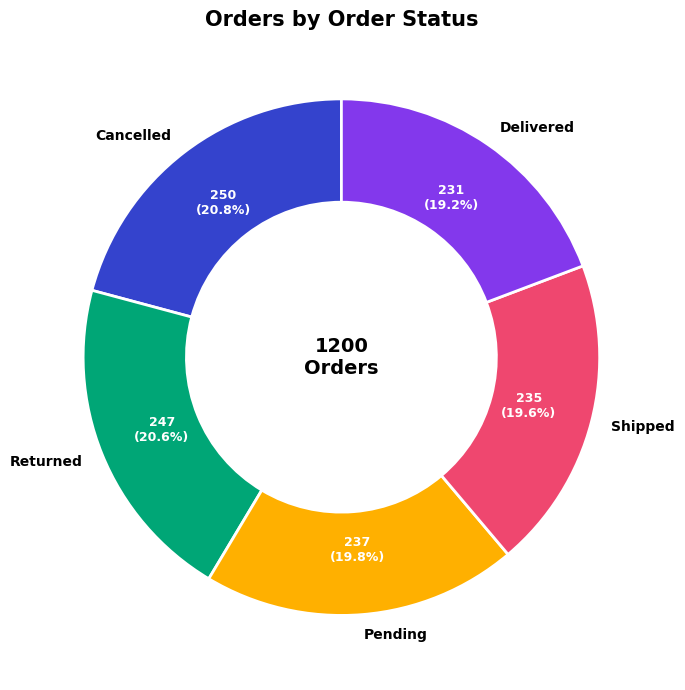

In [52]:
plt.figure(figsize=(8, 7))

# Beautiful colors
colors = ["#3443CD", "#00A676", "#FFB000", "#EF476F", "#8338EC"]

# Values and labels
values = order_status_summary["Orders"]
labels = order_status_summary["OrderStatus"]

# Total orders
total = values.sum()

# Function to show value and percentage
def show_value_and_percent(pct):
    value = int(round(pct * total / 100.0))
    return f"{value}\n({pct:.1f}%)"

# Doughnut chart
wedges, texts, autotexts = plt.pie(
    values,
    labels=labels,
    colors=colors[:len(values)],
    autopct=show_value_and_percent,
    startangle=90,
    pctdistance=0.75,
    labeldistance=1.08,
    wedgeprops={
        "width": 0.40,
        "edgecolor": "white",
        "linewidth": 2
    }
)

# Style the value texts
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(9)
    autotext.set_fontweight("bold")

# Style the labels
for text in texts:
    text.set_fontsize(10)
    text.set_fontweight("bold")

# Add center text
plt.text(
    0, 0,
    f"{total}\nOrders",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold"
)

plt.title("Orders by Order Status", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

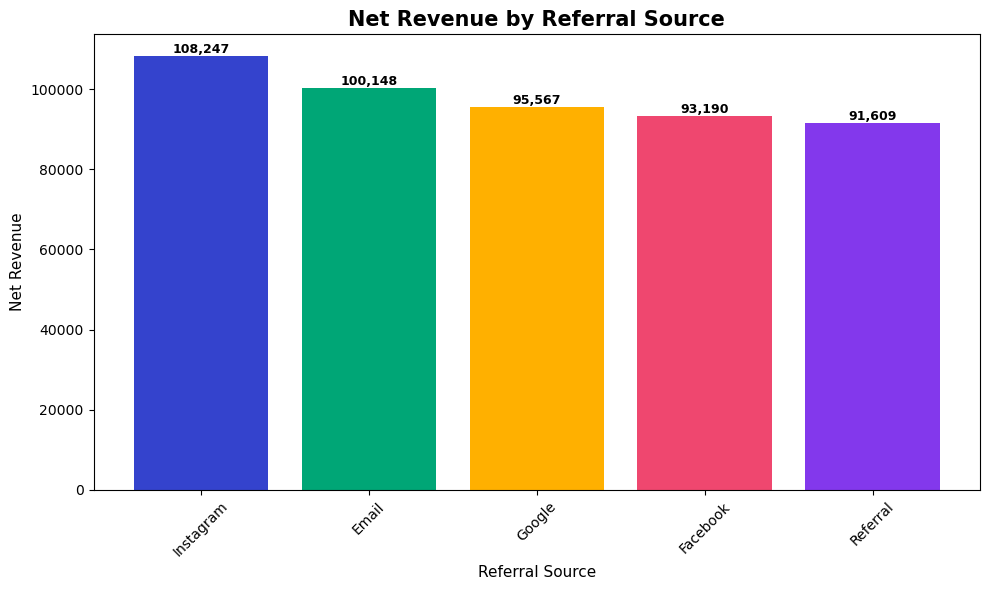

In [51]:
plt.figure(figsize=(10, 6))

# Beautiful colors
colors = ["#3443CD", "#00A676", "#FFB000", "#EF476F", "#8338EC", "#118AB2"]

# Create bar chart
bars = plt.bar(
    referral_summary["ReferralSource"],
    referral_summary["NetRevenue"],
    color=colors[:len(referral_summary)]
)

plt.title("Net Revenue by Referral Source", fontsize=15, fontweight="bold")
plt.xlabel("Referral Source", fontsize=11)
plt.ylabel("Net Revenue", fontsize=11)
plt.xticks(rotation=45)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

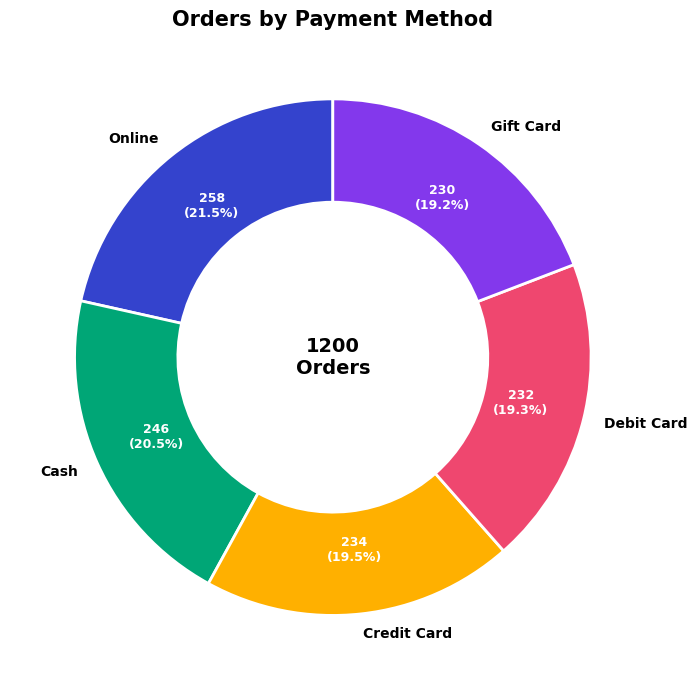

In [50]:
plt.figure(figsize=(9, 7))

# Beautiful colors
colors = ["#3443CD", "#00A676", "#FFB000", "#EF476F", "#8338EC", "#118AB2"]

# Values
values = payment_summary["Orders"]
labels = payment_summary["PaymentMethod"]

# Create labels with values and percentages
total = values.sum()

def show_value_and_percent(pct):
    value = int(round(pct * total / 100.0))
    return f"{value}\n({pct:.1f}%)"

# Doughnut chart
wedges, texts, autotexts = plt.pie(
    values,
    labels=labels,
    colors=colors[:len(values)],
    autopct=show_value_and_percent,
    startangle=90,
    pctdistance=0.75,
    labeldistance=1.08,
    wedgeprops={
        "width": 0.40,
        "edgecolor": "white",
        "linewidth": 2
    }
)

# Style value texts
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(9)
    autotext.set_fontweight("bold")

# Style labels
for text in texts:
    text.set_fontsize(10)
    text.set_fontweight("bold")

# Add center circle text
plt.text(
    0, 0,
    f"{total}\nOrders",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold"
)

plt.title("Orders by Payment Method", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

In [44]:
top_10_customers = customer_summary.head(10)

top_10_customers

,CustomerID,Orders,TotalQuantity,GrossRevenue,NetRevenue,FirstOrderDate,LastOrderDate
648,C57276,1,5,3456.40,3456.40,2023-08-17,2023-08-17
781,C67260,1,5,3390.80,3390.80,2023-05-02,2023-05-02
97,C16775,1,5,3353.75,3353.75,2023-03-27,2023-03-27
520,C47778,1,5,3334.00,3334.00,2023-10-30,2023-10-30
211,C25276,1,5,3313.90,3313.90,2023-05-26,2023-05-26
599,C53464,1,5,3299.25,3299.25,2024-06-29,2024-06-29
1028,C88029,1,5,3277.75,3277.75,2025-06-14,2025-06-14
1050,C89979,1,5,3170.00,3170.00,2024-06-20,2024-06-20
409,C39074,1,5,3032.60,3032.60,2023-10-25,2023-10-25
14,C11415,1,5,2876.20,2876.20,2024-03-15,2024-03-15


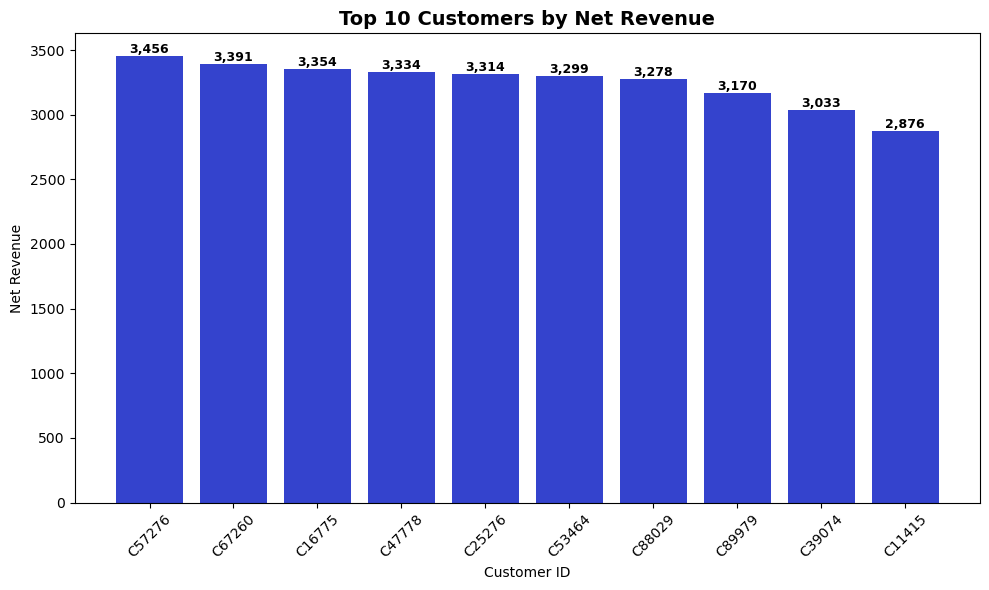

In [49]:
plt.figure(figsize=(10, 6))

# Create bar chart with color
bars = plt.bar(
    top_10_customers["CustomerID"].astype(str), 
    top_10_customers["NetRevenue"],
    color="#3443CD"
)

plt.title("Top 10 Customers by Net Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Customer ID")
plt.ylabel("Net Revenue")
plt.xticks(rotation=45)

# Add values on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [46]:
best_product = product_summary.iloc[0]["Product"]
best_product_revenue = product_summary.iloc[0]["NetRevenue"]

best_referral = referral_summary.iloc[0]["ReferralSource"]
best_referral_revenue = referral_summary.iloc[0]["NetRevenue"]

best_month = monthly_sales.sort_values(by="NetRevenue", ascending=False).iloc[0]["YearMonth"]
best_month_revenue = monthly_sales.sort_values(by="NetRevenue", ascending=False).iloc[0]["NetRevenue"]

print("BUSINESS INSIGHTS")
print("----------------")
print(f"Best-performing product by net revenue: {best_product} with revenue of {best_product_revenue:,.2f}")
print(f"Best-performing referral source: {best_referral} with revenue of {best_referral_revenue:,.2f}")
print(f"Best sales month: {best_month} with net revenue of {best_month_revenue:,.2f}")
print(f"Cancellation rate: {cancellation_rate:.2f}%")
print(f"Return rate: {return_rate:.2f}%")
print(f"Success rate: {success_rate:.2f}%")

BUSINESS INSIGHTS
----------------
Best-performing product by net revenue: Printer with revenue of 82,452.14
Best-performing referral source: Instagram with revenue of 108,246.78
Best sales month: 2023-10 with net revenue of 36,899.08
Cancellation rate: 20.83%
Return rate: 20.58%
Success rate: 38.83%


In [47]:
output_file = "ecommerce_order_analysis_output.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Cleaned Data", index=False)
    kpi_summary.to_excel(writer, sheet_name="KPI Summary", index=False)
    product_summary.to_excel(writer, sheet_name="Product Analysis", index=False)
    monthly_sales.to_excel(writer, sheet_name="Monthly Sales", index=False)
    order_status_summary.to_excel(writer, sheet_name="Order Status", index=False)
    payment_summary.to_excel(writer, sheet_name="Payment Method", index=False)
    referral_summary.to_excel(writer, sheet_name="Referral Source", index=False)
    coupon_summary.to_excel(writer, sheet_name="Coupon Analysis", index=False)
    customer_summary.to_excel(writer, sheet_name="Customer Analysis", index=False)

print(f"Analysis exported successfully to {output_file}")

Analysis exported successfully to ecommerce_order_analysis_output.xlsx
